<a href="https://colab.research.google.com/github/jessieliang-0720/git-tutorial/blob/main/API_Youbike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request

# 下載 Google 的思源黑體 (Noto Sans TC)，存到本機
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "/content/NotoSansCJKtc-Regular.otf"

if not os.path.exists(font_path):
    print("下載中文字型中…")
    urllib.request.urlretrieve(font_url, font_path)
    print("下載完成！")

# 把字型註冊給 matplotlib
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Noto Sans CJK TC"
plt.rcParams["axes.unicode_minus"] = False   # 讓負號正常顯示

下載中文字型中…
下載完成！


In [ ]:
import requests

URL = "https://tcgbusfs.blob.core.windows.net/dotapp/youbike/v2/youbike_immediate.json"

resp = requests.get(URL, timeout=10)
print("HTTP 狀態碼:", resp.status_code)     # 200 = 成功

records = resp.json()                        # JSON → Python 清單
print("總共幾個站點:", len(records))

HTTP 狀態碼: 200
總共幾個站點: 1774


In [ ]:
import pandas as pd

df = pd.DataFrame(records)

# 把要用的數字欄位轉成數字型別
for col in ["available_rent_bikes", "available_return_bikes", "total"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 只看幾個重要欄位
df[["sna", "sarea", "available_rent_bikes", "available_return_bikes"]].head(20)

,sna,sarea,available_rent_bikes,available_return_bikes
0,YouBike2.0_捷運科技大樓站,大安區,9,18
1,YouBike2.0_復興南路二段273號前,大安區,3,18
2,YouBike2.0_國北教大實小東側門,大安區,0,28
3,YouBike2.0_和平公園東側,大安區,11,0
4,YouBike2.0_辛亥復興路口西北側,大安區,14,1
5,YouBike2.0_復興南路二段280號前,大安區,9,18
6,YouBike2.0_復興南路二段340巷口,大安區,10,0
7,YouBike2.0_新生南路三段52號前,大安區,0,17
8,YouBike2.0_新生南路三段66號前,大安區,12,3
9,YouBike2.0_新生南路三段82號前,大安區,15,5


In [ ]:
by_area = df.groupby("sarea")["available_rent_bikes"].sum().sort_values(ascending=False)
print(by_area)

sarea
中山區       1998
大安區       1978
內湖區       1778
士林區       1521
中正區       1420
信義區       1303
北投區       1302
文山區       1066
萬華區       1064
南港區       1027
大同區        823
松山區        782
臺大公館校區     595
Name: available_rent_bikes, dtype: int64


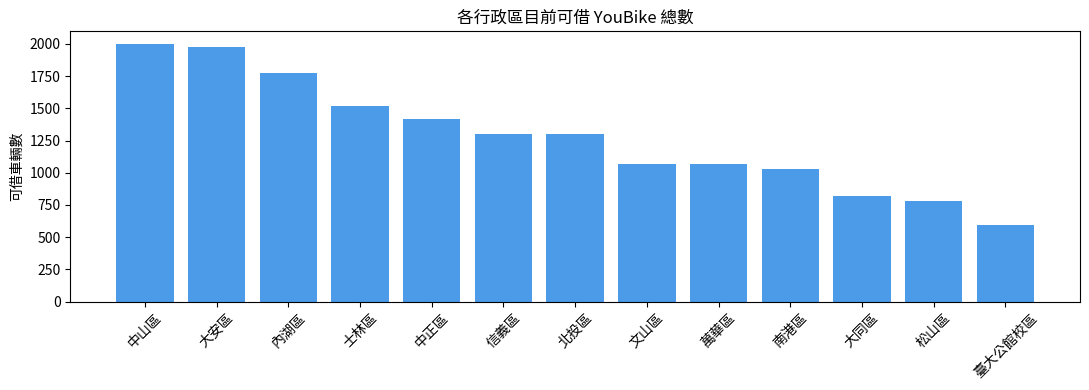

In [ ]:
# 畫成長條圖
plt.figure(figsize=(11, 4))
plt.bar(by_area.index, by_area.values, color="#4C9BE8")
plt.title("各行政區目前可借 YouBike 總數")
plt.ylabel("可借車輛數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 找出目前「沒車可借」的站點 (可借 = 0) → 這就是產品可以解決的問題
empty = df[df["available_rent_bikes"] == 0]
print(f"目前完全沒車可借的站點：{len(empty)} 個 (共 {len(df)} 站)\n")
print(empty[["sna", "sarea"]].head(10).to_string(index=False))

目前完全沒車可借的站點：111 個 (共 1774 站)

                   sna sarea
  YouBike2.0_國北教大實小東側門   大安區
 YouBike2.0_新生南路三段52號前   大安區
  YouBike2.0_辛亥路一段30號前   大安區
YouBike2.0_羅斯福路三段311號前   大安區
YouBike2.0_羅斯福路三段245號前   大安區
      YouBike2.0_溫州停車場   大安區
     YouBike2.0_臺大男一舍前   大安區
   YouBike2.0_基隆長興路口東側   大安區
YouBike2.0_捷運古亭站(5號出口)   大安區
YouBike2.0_捷運東門站(3號出口)   大安區


In [ ]:
def find_bikes(area, top=10):
    records = requests.get(URL, timeout=10).json()      # 每次抓最新資料
    d = pd.DataFrame(records)
    d["available_rent_bikes"] = pd.to_numeric(d["available_rent_bikes"], errors="coerce")

    result = d[d["sarea"] == area].sort_values("available_rent_bikes", ascending=False)
    if len(result) == 0:
        return f"找不到「{area}」，請確認行政區名稱 (例如：大安區)"

    lines = [f"📍 {area} 目前最多車可借的前 {top} 站："]
    for _, row in result.head(top).iterrows():
        lines.append(f"   {row['sna']}｜可借 {int(row['available_rent_bikes'])} 台")
    return "\n".join(lines)

# 試用看看 (換成任何行政區)
print(find_bikes("大安區"))

📍 大安區 目前最多車可借的前 10 站：
   YouBike2.0_臺灣科技大學側門｜可借 56 台
   YouBike2.0_臺大資訊大樓｜可借 48 台
   YouBike2.0_愛國金山路口｜可借 46 台
   YouBike2.0_信義敦化路口｜可借 38 台
   YouBike2.0_臺灣科技大學正門｜可借 36 台
   YouBike2.0_臺北市立圖書館(總館)｜可借 32 台
   YouBike2.0_建國和平路口西北側｜可借 32 台
   YouBike2.0_臺北科技大學(電機工程系)｜可借 30 台
   YouBike2.0_臺大永齡生醫工程館｜可借 30 台
   YouBike2.0_臺大環研大樓｜可借 29 台


In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    areas = sorted(df["sarea"].dropna().unique().tolist())
    dd = widgets.Dropdown(options=areas, description="行政區:")
    out = widgets.Output()

    def on_change(ch):
        if ch["name"] == "value" and ch["type"] == "change":
            out.clear_output()
            with out:
                print(find_bikes(ch["new"]))

    dd.observe(on_change)
    display(dd, out)
    with out:
        print(find_bikes(dd.value))
except Exception:
    print(find_bikes("信義區"))

Dropdown(description='行政區:', options=('中山區', '中正區', '信義區', '內湖區', '北投區', '南港區', '士林區', '大同區', '大安區', '文山區', '松…

Output()